In [2]:
import PyPDF2
import ast
import tiktoken
import requests
import re
import os,glob
import time
from random import sample
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from openai import OpenAI
api_key = "*** ***"
organization = "*** ***"
client = OpenAI(api_key=api_key,organization=organization)

In [3]:
def count_tokens(text):
    encoding = tiktoken.get_encoding("cl100k_base")
    num_tokens = len(encoding.encode(text))
    return num_tokens

In [4]:
def get_txt_from_pdf(pdf_files,filter_ref = False, combine=False):
    data = []
    pdf_content_dict = {}
    for pdf in pdf_files:
        all_pdf_txt = ''
        print(pdf)
        with open(pdf, 'rb') as pdf_content:
            pdf_reader = PyPDF2.PdfReader(pdf_content)
            for page_num in range(len(pdf_reader.pages)):
                page = pdf_reader.pages[page_num]
                page_text = page.extract_text()
                all_pdf_txt += page_text
            all_pdf_txt = re.split('\n',all_pdf_txt)
            all_pdf_txt = [txt1 for txt in all_pdf_txt for txt1 in re.split('\n \n',txt)]
            for i, para_part in enumerate(all_pdf_txt):
                data.append({
                    'file name': pdf,
                    'paragraph number': i+1,
                    'content': para_part
                })
    df = pd.DataFrame(data)
    return df

In [5]:
def combine_text(df):
    start_index = 0
    all_groups = []
    data = []
    for i in range(len(df)):
        pdf = df['file name'][i]
        content_split = df['content'][i].split()
        if content_split != []:
            content_end = content_split[-1][-1]
            if content_end == '.' or content_end == '*':
                all_groups.append(range(start_index,i+1))
                new_content = ''
                for j in range(start_index,i+1):
                    new_content += df['content'][j]
                data.append({
                            'file name': pdf,
                            'content': new_content
                            })
                start_index = i+1
    new_df = pd.DataFrame(data)
    return new_df

In [6]:
def organize_text_to_input(new_df):
    index = 1
    part_num = 1
    txt = ''
    inputs = {}
    for i in range(len(new_df)):
        content = new_df.loc[i,'content']
        filename1 = new_df.loc[i,'file name']
        if i>0:
            filename2 = new_df.loc[i-1,'file name']
            if  filename1!=filename2  or i == len(new_df)-1:
                index = 1
                inputs[filename2+'part'+str(part_num)] = txt
                txt = ''
                part_num = 1
            if  token_num > 3300-count_tokens(content) or index >= 20:
                index = 1
                inputs[filename1+'part'+str(part_num)] = txt
                part_num += 1
                txt = ''
        txt += str(index)+'、'+content+'\n \n'
        token_num = count_tokens(txt)
        new_df.loc[i,'index'] = index
        new_df.loc[i,'new_content'] = str(index)+'、'+content
        new_df.loc[i,'part'] = filename1+'part'+str(part_num)
        index += 1
    return inputs

In [7]:
def run_GPT(inputs):
    all_inputs_list = list(inputs.keys())
    outputs = {}
    with open('./classification.txt','r',encoding='utf-8') as f:
        prompt = f.read()
    assistant = """You are a classifier and you have learned the examples given in the system, \
    now you are given a text containing many numbered paragraphs separated by a blank line, \
    please output the category of each paragraph.Each category must be unambiguous, separated by a semicolon. \
    If there is more than one category in a paragraph, output the main category.\
    Write only the category in your answer, not the original text."""
    
    for index, key in enumerate(all_inputs_list):
        text = inputs[key]
        try:
            response = client.chat.completions.create(
                               model='gpt-4',
                                messages=[      {"role": "assistant", "content": assistant},
                                                {"role": "system", "content": prompt},
                                                {"role": "user", "content": text}
                                            ]
                            )
            answers = response.choices[0].message.content
            with open('gpt-4-new.log','a+',encoding='gb18030') as f:
                contents = 'text:\n'+text+'answers:\n'+answers
                f.write(key+':\n\n'+'INPUTS:\n'+contents+'\n\n')
            outputs[key] = answers
            print(index+1,key)
        except Exception as e:
            print(f"Error: {str(e)}")
    return outputs

In [8]:
def organize_answer(inputs,outputs):
    data = []
    for index, key in enumerate(inputs.keys()):
        if key in outputs.keys():
            text = inputs[key].split('\n \n')
            text = [text_ for text_ in text if text_ != '']
            answers = outputs[key]
            answers_split1 = answers.split('\n')
            answers_split2 = answers.split(';')
            distance1 = abs(len(answers_split1)-len(text))
            distance2 = abs(len(answers_split2)-len(text))
            if distance1 < distance2:
                answers = answers_split1
            else:
                answers = answers_split2
            answers = [answer for answer in answers if answer != '']
            if len(text) > len(answers):
                for i in range(len(text)):
                    para = text[i]
                    if i<len(answers):
                        answer = answers[i]
                        data.append({
                                'file name': key,
                                'content': para,
                                'categories': answer
                                })
                    else:
                        data.append({
                                'file name': key,
                                'content': para,
                                'categories': 'no answer'
                                })
            else:
                for i in range(len(answers)):
                    answer = answers[i]
                    if i<len(text):
                        para = text[i]
                        data.append({
                                    'file name': key,
                                    'content': para,
                                    'categories': answer
                                    })
                    else:
                        data.append({
                                    'file name': key,
                                    'content': 'extra answer',
                                    'categories': answer
                                    })
    class_df = pd.DataFrame(data)
    return class_df

In [9]:
def main(pdf_list):
    df = get_txt_from_pdf(pdf_list)
    new_df = combine_text(df)
    inputs = organize_text_to_input(new_df)
    outputs = run_GPT(inputs)
    class_df = organize_answer(inputs,outputs)
    return class_df

In [10]:
# replace the variables of the main() function with a list of your pdf files
class_df = main([r"E:\liuming\cage-GPT\papers\with_SI\2008---Chem Comm.pdf"])

E:\liuming\cage-GPT\papers\with_SI\2008---Chem Comm.pdf
1 E:\liuming\cage-GPT\papers\with_SI\2008---Chem Comm.pdfpart1
2 E:\liuming\cage-GPT\papers\with_SI\2008---Chem Comm.pdfpart2
3 E:\liuming\cage-GPT\papers\with_SI\2008---Chem Comm.pdfpart3
4 E:\liuming\cage-GPT\papers\with_SI\2008---Chem Comm.pdfpart4
5 E:\liuming\cage-GPT\papers\with_SI\2008---Chem Comm.pdfpart5


In [11]:
# input a well-organized excel file containing real_categories and pred_categories
# output a heatmap with details of text classification
def make_heatmap(excel_file): 
    df = pd.read_excel(excel_file)
    real_categories_list = set(df['real_categories'])
    for i in range(len(df)):
        pred_categories = df.loc[i,'pred_categories']
        if pred_categories not in real_categories_list:
            df.loc[i,'pred_categories'] = 'other outputs' # categorizing all non-listed data under the umbrella term 'other data'
    
    plt.rcParams['font.family'] = 'Times New Roman'
    df['real_categories'] = df['real_categories'].astype('category')
    df['pred_categories'] = df['pred_categories'].astype('category')
    
    confusion_matrix = pd.crosstab(df['real_categories'], df['pred_categories'])
    row_sums = np.sum(confusion_matrix, axis=1)
    normalized_confusion_matrix = confusion_matrix*100 / np.array(row_sums)[:, np.newaxis]
    normalized_confusion_matrix = normalized_confusion_matrix.iloc[:, [0,1,2,3,4,5,7,8,9,6]]
    plt.figure(figsize=(10, 8))
    sns.heatmap(normalized_confusion_matrix, annot=True, fmt='.2f', cmap='coolwarm',vmin=0, vmax=50,\
                xticklabels=normalized_confusion_matrix.columns, yticklabels=normalized_confusion_matrix.index)
    plt.title('Text Classification (%)')
    plt.xlabel('pred_categories')
    plt.ylabel('real_categories')
    plt.savefig('heatmap.png', dpi=300, bbox_inches='tight')
    plt.show()

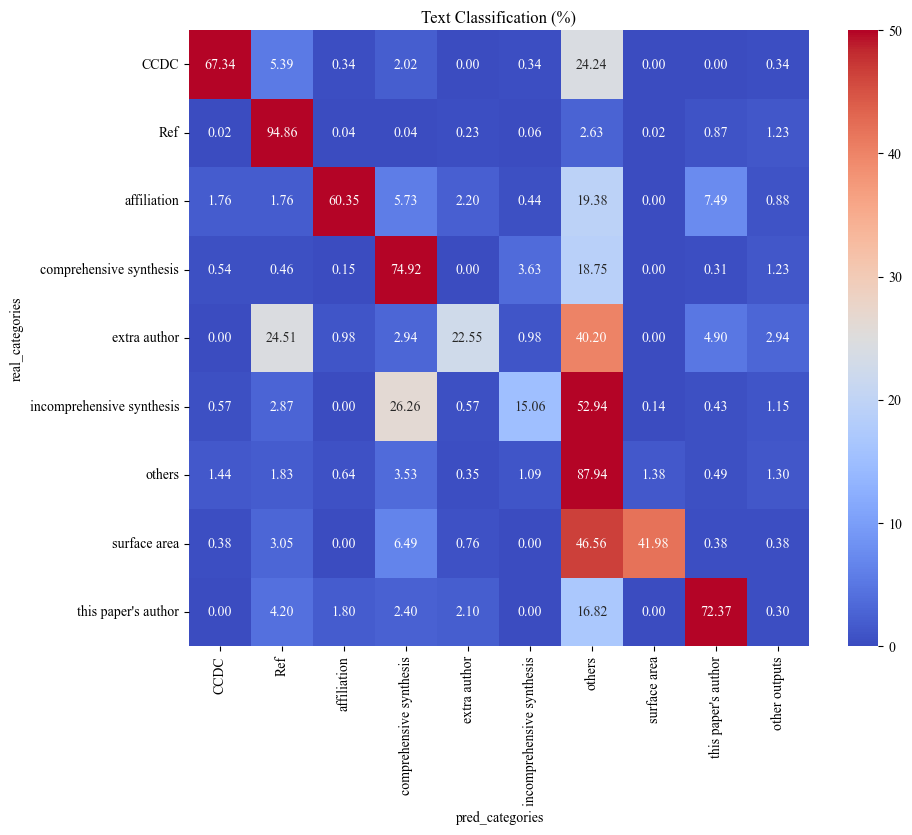

In [12]:
make_heatmap('Text_Fragments_labels.xlsx')